# EDS Quantification Pipeline


In [ ]:
# %%
# =============================================================================
# EDS Quantification Pipeline
# =============================================================================
# Workflow:
#   1. load_eds_data()        — load spectra, pixel positions, HAADF
#   2. build_template()       — build one sidpy Dataset (reused for all points)
#   3. detect_elements()      — auto-detect elements from each spectrum, take union
#   4. add_element()          — manually add elements if needed
#   5. quantify_all()         — loop over N points, return results DataFrame
#   6. plot_composition()     — journal-quality scatter plots on HAADF
# =============================================================================

In [107]:
import os
import numpy as np
import pandas as pd
import tifffile
import sidpy
import matplotlib.pyplot as plt


# 1. Load data from folder


In [108]:
# %%
# -----------------------------------------------------------------------------
# 1. Load data from folder
# -----------------------------------------------------------------------------

def load_eds_data(folder_path: str, dispersion: float, offset: float) -> dict:
    """
    Load all EDS data from a folder.

    Expected files:
        - one .tiff containing 'haadf' in the name
        - pixel_pos.npy       : shape (N, 2), pixel coordinates [x, y]
        - raw_spectra.npy     : shape (N, energy_channels)

    Parameters
    ----------
    folder_path  : path to the data folder
    dispersion   : eV per channel (e.g. 10.0)
    offset       : energy offset in eV (e.g. -250.0)

    Returns
    -------
    dict with keys: haadf, pixel_pos, raw_spectra, energy, dispersion, offset
    """
    folder_path = str(folder_path)

    # -- HAADF --
    haadf_files = [
        f for f in os.listdir(folder_path)
        if f.lower().endswith(".tiff") and "haadf" in f.lower()
    ]
    if len(haadf_files) == 0:
        raise FileNotFoundError("No HAADF .tiff found in folder.")
    if len(haadf_files) > 1:
        raise ValueError(f"Multiple HAADF files found: {haadf_files}")

    haadf = tifffile.imread(os.path.join(folder_path, haadf_files[0]))

    # -- positions and spectra --
    pixel_pos   = np.load(os.path.join(folder_path, "pixel_pos.npy"))       # (N, 2)
    raw_spectra = np.load(os.path.join(folder_path, "raw_spectra.npy"))     # (N, channels)

    # -- energy axis --
    n_channels = raw_spectra.shape[1]
    energy = np.arange(n_channels, dtype=float) * dispersion + offset

    return {
        "haadf"       : haadf,
        "pixel_pos"   : pixel_pos,
        "raw_spectra" : raw_spectra,
        "energy"      : energy,
        "dispersion"  : dispersion,
        "offset"      : offset,
    }

# 2. Build sidpy template (reused for all points)


In [109]:
# %%
# -----------------------------------------------------------------------------
# 2. Build sidpy template (reused for all points)
# -----------------------------------------------------------------------------

# Hardcoded detector metadata — edit as needed
DETECTOR_METADATA = {
    "layers"            : {13: {"thickness": 5e-08, "Z": 13, "element": "Al"}},
    "SiDeadThickness"   : 1.3e-07,
    "SiLiveThickness"   : 0.05,
    "detector_area"     : 3e-05,
    "energy_resolution" : 125,
    "start_energy"      : 120,
    "start_channel"     : 100,
    "ElevationAngle"    : 0.31415927,
    "AzimuthAngle"      : 3.9269908169872414,
    "RealTime"          : 26.2338126,
    "LiveTime"          : 25.20496870466589,
}


def build_template(data: dict) -> sidpy.Dataset:
    """
    Build a sidpy.Dataset template from the first spectrum.
    The data array will be swapped out for each point in the loop.
    Also computes and attaches detector efficiency.
    """
    energy     = data["energy"]
    spectrum_0 = data["raw_spectra"][0]

    ds = sidpy.Dataset.from_array(spectrum_0.copy())
    ds.data_type = "spectrum"
    ds.quantity  = "Intensity"
    ds.units     = "counts"
    ds.set_dimension(
        0,
        sidpy.Dimension(energy, name="Energy", units="eV",
                        quantity="Energy", dimension_type="spectral")
    )

    # attach detector metadata
    ds.metadata = {"EDS": {"detector": DETECTOR_METADATA.copy()}}

    # set start channel and zero low-energy region
    start = np.searchsorted(energy, DETECTOR_METADATA["start_energy"])
    ds.metadata["EDS"]["detector"]["start_channel"] = start
    # ds[:start] = 100.0
    # in build_template
    ds[:start] = 0.0

    # compute detector efficiency once (same for all spectra)
    detector_efficiency = pyTEMlib.eds_tools.detector_response(ds)
    ds.metadata["EDS"]["detector"]["detector_efficiency"] = detector_efficiency

    return ds

# 3. Auto-detect elements (union across all spectra)


In [110]:

# %%
# -----------------------------------------------------------------------------
# 3. Auto-detect elements (union across all spectra)
# -----------------------------------------------------------------------------

def detect_elements(data: dict, template: sidpy.Dataset,
                    minimum_peaks: int = 10) -> list[str]:
    """
    Run get_elements on every spectrum, return the union of detected elements.

    Parameters
    ----------
    minimum_peaks : minimum number of peaks required to identify an element
    """
    all_elements = set()
    start = template.metadata["EDS"]["detector"]["start_channel"]

    for i, spectrum_data in enumerate(data["raw_spectra"]):
        # swap data into template
        template[:] = spectrum_data.copy()
        template[:start] = 100.0


        detected = pyTEMlib.eds_tools.get_elements(template, minimum_peaks, verbose=False)

        # # fit first — populates metadata['EDS'] with peaks
        # peaks, pp = pyTEMlib.eds_tools.fit_model(template, use_detector_efficiency=True)

        # # now get_elements can find the peaks
        # detected = pyTEMlib.eds_tools.get_elements(template, minimum_peaks, verbose=False)
        
        all_elements.update(detected)

    element_list = sorted(all_elements)
    print(f"Detected elements (union across all points): {element_list}")
    return element_list


In [111]:
def detect_elements(data: dict, template: sidpy.Dataset,
                    minimum_peaks: int = 10) -> list[str]:
    
    all_elements = set()
    start = template.metadata["EDS"]["detector"]["start_channel"]

    for i, spectrum_data in enumerate(data["raw_spectra"]):
        template[:] = spectrum_data.copy()
        template[:start] = 0.0
        # peaks, pp = pyTEMlib.eds_tools.fit_model(template, use_detector_efficiency=True)
        detected = pyTEMlib.eds_tools.get_elements(template, minimum_peaks, verbose=False)
        all_elements.update(detected)

    element_list = sorted(all_elements)
    print(f"Detected elements (union across all points): {element_list}")

    # -- debug: plot last spectrum with detected element lines --
    fig, ax = plt.subplots(figsize=(10, 4), dpi=150)
    ax.plot(template.Energy.values, np.array(template), lw=0.8)
    pyTEMlib.eds_tools.plot_lines(template.metadata['EDS'], ax)
    ax.set_xlabel("Energy (eV)")
    ax.set_ylabel("Counts")
    ax.set_title("Detected elements — last spectrum")
    ax.set_xlim(0, 20000)
    plt.tight_layout()
    plt.show()

    return element_list

# 4. Manually add elements


In [112]:

# %%
# -----------------------------------------------------------------------------
# 4. Manually add elements
# -----------------------------------------------------------------------------

def add_element(template: sidpy.Dataset, elements: list[str] | str):
    """
    Add one or more elements to the EDS metadata manually.
    Call this after detect_elements() to include elements you know are present.

    Example
    -------
    add_element(template, ['Fe', 'Ni', 'Cr'])
    """
    if isinstance(elements, str):
        elements = [elements]
    template.metadata["EDS"].update(
        pyTEMlib.eds_tools.get_x_ray_lines(template, elements)
    )
    print(f"Added elements: {elements}")



# 5. Quantify all spectra — returns a DataFrame


In [120]:
def quantify_all(data: dict, elements_to_add: list[str],
                 dispersion: float, offset: float,
                 mask: list[str] | None = None) -> pd.DataFrame:
    """
    Loop over all N spectra, build a fresh sidpy Dataset for each one
    (following the same steps as single-spectrum workflow), and quantify.

    Parameters
    ----------
    elements_to_add : elements to add manually e.g. ['Fe', 'Ni', 'Cr']
    dispersion      : eV per channel
    offset          : energy offset in eV
    mask            : elements to exclude from quantification e.g. ['C', 'F', 'Ne']
    """
    import io, contextlib

    if mask is None:
        mask = []

    q_dict = pyTEMlib.eds_tools.load_k_factors()
    xs, ys = data["pixel_pos"][:, 0], data["pixel_pos"][:, 1]
    energy = data["energy"]
    rows   = []

    for i, spectrum_data in enumerate(data["raw_spectra"]):

        # -- build fresh sidpy Dataset (same as old code) --
        ds = sidpy.Dataset.from_array(spectrum_data.copy())
        ds.data_type = "spectrum"
        ds.quantity  = "Intensity"
        ds.units     = "counts"
        ds.set_dimension(0, sidpy.Dimension(energy, name="Energy", units="eV",
                                            quantity="Energy", dimension_type="spectral"))

        # -- attach detector metadata (same as old code) --
        ds.metadata = {"EDS": {"detector": DETECTOR_METADATA.copy()}}
        detector_efficiency = pyTEMlib.eds_tools.detector_response(ds)
        ds.metadata["EDS"]["detector"]["detector_efficiency"] = detector_efficiency

        start = np.searchsorted(energy, DETECTOR_METADATA["start_energy"])
        ds.metadata["EDS"]["detector"]["start_channel"] = start
        ds[:start] = 100.0

        # -- auto-detect elements --
        pyTEMlib.eds_tools.get_elements(ds, 10, verbose=False)

        # -- manually add elements --
        ds.metadata["EDS"].update(pyTEMlib.eds_tools.get_x_ray_lines(ds, elements_to_add))

        # -- fit --
        peaks, pp = pyTEMlib.eds_tools.fit_model(ds, use_detector_efficiency=True)

        # -- quantify (capture stdout) --
        buf = io.StringIO()
        with contextlib.redirect_stdout(buf):
            pyTEMlib.eds_tools.quantify_eds(ds, q_dict, mask=mask)
        output = buf.getvalue()

        # -- parse stdout --
        point_result = {"x": xs[i], "y": ys[i]}
        for line in output.splitlines():
            if ":" in line and "at%" in line:
                element, rest = line.split(":")
                parts = rest.strip().split()
                point_result[f"{element.strip()}_at%"] = float(parts[0])
                point_result[f"{element.strip()}_wt%"] = float(parts[2])

        rows.append(point_result)

        if (i + 1) % 10 == 0 or (i + 1) == len(data["raw_spectra"]):
            print(f"  Quantified {i+1}/{len(data['raw_spectra'])} spectra")

    return pd.DataFrame(rows)

# 6. Plot composition 


In [121]:
# %%
# -----------------------------------------------------------------------------
# 6. Plot composition 
# -----------------------------------------------------------------------------

def plot_composition(results: pd.DataFrame, haadf: np.ndarray,
                     quantity: str = "at%", cmap: str = "plasma",
                     point_size: int = 60) -> plt.Figure:
    """
    Plot HAADF with scatter points colored by elemental composition.
    One subplot per element, adaptive layout.

    Parameters
    ----------
    results   : DataFrame from quantify_all()
    haadf     : 2D HAADF image array
    quantity  : 'at%' or 'wt%'
    cmap      : colormap (default 'plasma')
    point_size: scatter marker size

    Returns
    -------
    matplotlib Figure
    """
    # find columns matching the requested quantity
    cols = [c for c in results.columns if c.endswith(f"_{quantity}")]
    elements = [c.replace(f"_{quantity}", "") for c in cols]

    n = len(elements)
    n_cols = min(4, n)
    n_rows = int(np.ceil(n / n_cols))

    fig, axes = plt.subplots(n_rows, n_cols,
                             figsize=(4 * n_cols, 4 * n_rows),
                             dpi=150)
    axes = np.array(axes).flatten()

    xs = results["x"].values
    ys = results["y"].values

    for i, (el, col) in enumerate(zip(elements, cols)):
        ax = axes[i]
        values = results[col].values

        ax.imshow(haadf, cmap="gray", origin="upper",
                  interpolation="nearest")
        sc = ax.scatter(xs, ys, c=values, s=point_size,
                        cmap=cmap, edgecolors="none",
                        vmin=values.min(), vmax=values.max())

        cbar = fig.colorbar(sc, ax=ax, fraction=0.046, pad=0.04)
        cbar.set_label(f"{quantity}", fontsize=9)
        cbar.ax.tick_params(labelsize=8)

        ax.set_title(f"{el}", fontsize=11, fontweight="bold")
        ax.tick_params(labelsize=7)
        ax.set_xlabel("x (px)", fontsize=8)
        ax.set_ylabel("y (px)", fontsize=8)

    # hide unused subplots
    for j in range(n, len(axes)):
        axes[j].axis("off")

    fig.suptitle(f"Elemental composition — {quantity}", fontsize=13,
                 fontweight="bold", y=1.01)
    plt.tight_layout()
    return fig



# 6. See the spectra

In [122]:
def plot_spectra(data: dict, max_spectra: int = 20):
    """
    Plot all (or up to max_spectra) raw spectra overlaid on one axes.
    Useful sanity check before quantification.
    """
    energy  = data["energy"]
    spectra = data["raw_spectra"]
    n       = min(len(spectra), max_spectra)

    fig, ax = plt.subplots(figsize=(8, 4), dpi=150)
    for i in range(n):
        ax.plot(energy, spectra[i], lw=0.7, alpha=0.6)

    ax.set_xlabel("Energy (eV)", fontsize=10)
    ax.set_ylabel("Counts", fontsize=10)
    ax.set_title(f"Raw spectra (showing {n} of {len(spectra)})", fontsize=11)
    plt.tight_layout()
    return fig

In [123]:
# 1. Load data
data = load_eds_data(
    folder_path = "20260228_114447_stem_edx_1772297087",
    dispersion  = 10.0,
    offset      = -250.0,
)


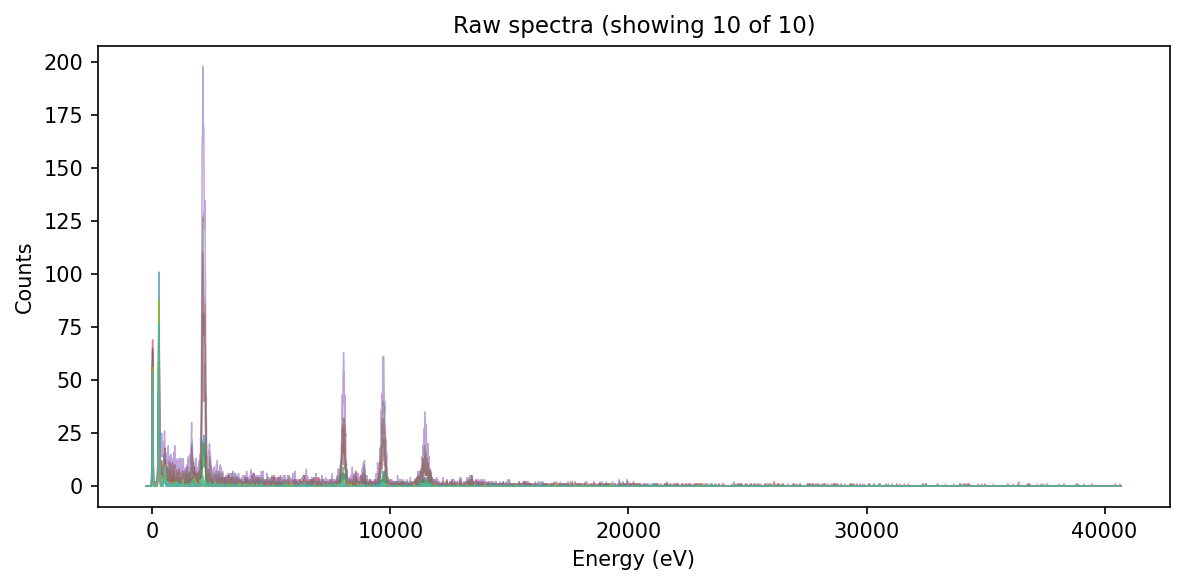

In [124]:
fig = plot_spectra(data, max_spectra=20)
plt.show()

# 6. --- RUN SEQUENCE ---


Detected elements (union across all points): ['Au', 'C', 'Cu', 'Nb', 'Rb']


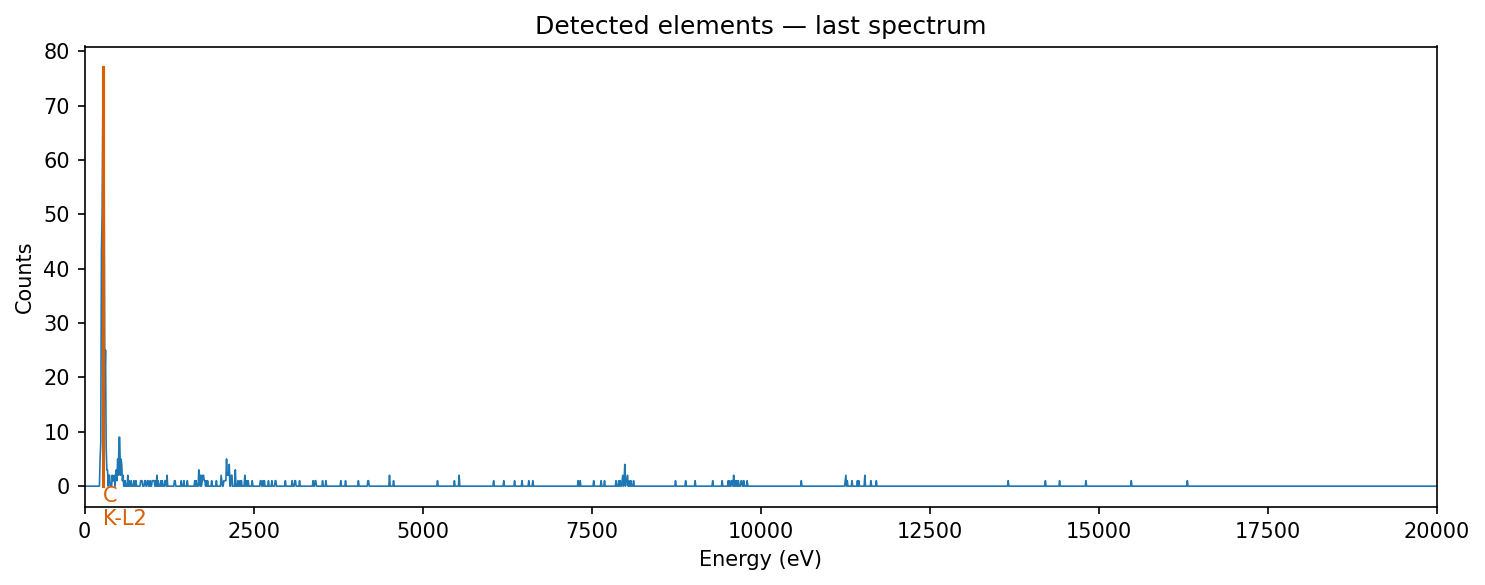

ValueError: sidpy.Dataset of type SPECTRUM with:
 dask.array<getitem, shape=(), dtype=uint32, chunksize=(), chunktype=numpy.ndarray>
 data contains: Intensity (counts)
 and Dimensions: 
 with metadata: ['EDS'] is not in list

In [ ]:

# %%
# =============================================================================
# --- RUN SEQUENCE ---
# =============================================================================


# 2. Build template sidpy Dataset
template = build_template(data)

# 3. Auto-detect elements across all spectra
elements = detect_elements(data, template, minimum_peaks=10)

# 4. Manually add elements you know are present (optional)
# add_element(template, ["Au"])

# 5. Quantify all spectra
# results = quantify_all(data, template, mask=["C", "F", "Ne"])
results = quantify_all(data, template,  mask=["C"], )

print(results)

# 6. Plot at%
fig_at = plot_composition(results, data["haadf"], quantity="at%")
plt.show()

# 6b. Plot wt% (optional)
fig_wt = plot_composition(results, data["haadf"], quantity="wt%")
plt.show()


In [78]:
 print(results.head())

            x            y  C_at%  C_wt%  Au_at%  Au_wt%
0  356.198524   788.057009      0      0     NaN     NaN
1  388.072618   394.299162      0      0     NaN     NaN
2  507.103634  1002.744882      0      0     NaN     NaN
3  621.326342   228.596451      0      0     NaN     NaN
4  741.156745   711.846871      0      0     NaN     NaN
